# Sentiment Analysis for the #GeorgeFloydFuneral

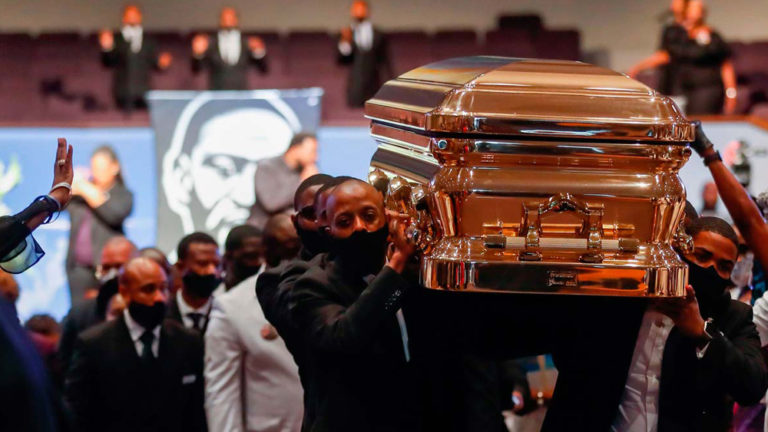

As we all know what is going on in America, protest after the death of George Floyd, and I also fully stand for equality and I am also against what happened. So I thought of extracting twitter data for the hashtag #GeorgeFloydFuneral and do some analysis, and my intention is to do sentiment analysis for the tweets for this hashtag.

First of all we will import all the necessary libraries for our analysis.

In [1]:
import pandas as pd
import re
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk.corpus
nltk.download("stopwords")
from nltk.corpus import stopwords
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
data=pd.read_csv("../input/tweets-for-georgefloydfuneral/George Floyd Twitter Data.csv")
data.head()

,Unnamed: 0,Tweets
0,0,The truth is IN YOUR FACE. Don't look away!\n#...
1,1,@WomenNMedia @TheWrap @sharonwaxman Sorry to s...
2,2,Former Vice President Joe Biden made a touchin...
3,3,@MSNBC Just couple of days back #GeorgeFloydFu...
4,4,We know you went to Dallas because #GeorgeFloy...


In [3]:
data_copy=data.copy()

Now we will clean the data a bit, as we all know twitter data is not use to be very clean. So cleaning is very important before moving ahead.

In [4]:
def cleaned_data(text):
    clean=re.sub("http\S+","",text)
    clean=clean.lower()
    clean=re.sub("\d","",clean)
    clean=re.sub("[^a-z]"," ",clean)
    clean=re.sub("\s{2,}"," ",clean)
    clean=clean.lstrip()
    clean=re.sub("don t","do not",clean)
    clean=re.sub("amp","",clean)
    clean=re.sub("i m","i am",clean)
    clean=re.sub("didn t","did not",clean)
    clean=re.sub("couldn t","could not",clean)
    clean=re.sub("son s","son",clean)
    #clean=re.sub("n","and",clean)
    clean=re.sub("pu sy","pussy",clean)
    clean=re.sub("fu ker","fucker",clean)
    clean=re.sub("can t","can not",clean)
    clean=re.sub("sh t","shit",clean)
    #clean=re.sub("inj","injustice",clean)
    clean=re.sub("you re","you are",clean)
    clean=re.sub("doesn t","does not",clean)
    clean=re.sub("wasn t","was not",clean)
    #clean=re.sub("presi","president",clean)
    clean=re.sub("let s","let us",clean)
    clean=re.sub("people s","people",clean)
    clean=re.sub("birble","bible",clean)
    clean=re.sub("servi","service",clean)
    clean=re.sub("it s","it is",clean)
    clean=re.sub("we re","we are",clean)
    clean=re.sub("ameri","america",clean)
    clean=re.sub("b c","because",clean)
    #clean=re.sub("cha","change",clean)
    clean=re.sub("sacri","sacrifice",clean)
    clean=re.sub("cant","can not",clean)
    clean=re.sub("today s","today",clean)
    clean=re.sub("floyd s","floyd",clean)
    clean=clean=re.sub("nationalguard","national guard",clean)
    clean=re.sub("minori","minority",clean)
    clean=re.sub("georgeflyod s","georgefloyd",clean)
    #clean=re.sub("p","protest",clean)
    #clean=re.sub("nd","second",clean)
    clean=re.sub("shouldn t","should not",clean)
    #clean=re.sub("racis","racism",clean)
    clean=re.sub("how d","how did",clean)
    #clean=re.sub("mu","music",clean)
    clean=re.sub("wanna","want to",clean)
    clean=re.sub("addre","address",clean)
    clean=re.sub("isince","since",clean)
    clean=re.sub("didid","did",clean)
    clean=re.sub("ya ll","you all",clean)
    clean=re.sub("ican notbreathe","i can not breathe",clean)
    clean=re.sub("caign","campaign",clean)
    clean=re.sub("caigning","campaigning",clean)
    clean=re.sub("didemocrats","democrats",clean)
    clean=re.sub("i amean","i mean",clean)
    clean=re.sub("americacans","americans",clean)
    clean=re.sub("concealin","concealing",clean)
    clean=re.sub("notell","tell",clean)
    clean=re.sub("what s","what is",clean)
    clean=re.sub("americaca","america",clean)
    clean=re.sub("\s{2,}"," ",clean)
    return clean
data["cleaned_tweets"]=data["Tweets"].apply(cleaned_data)

So to check whether cleaning has been done or not, we will check the first 10 rows.

In [5]:
data.head(10)

,Unnamed: 0,Tweets,cleaned_tweets
0,0,The truth is IN YOUR FACE. Don't look away!\n#...,the truth is in your face do not look away geo...
1,1,@WomenNMedia @TheWrap @sharonwaxman Sorry to s...,womennmedia thewrap sharonwaxman sorry to say ...
2,2,Former Vice President Joe Biden made a touchin...,former vice president joe biden made a touchin...
3,3,@MSNBC Just couple of days back #GeorgeFloydFu...,msnbc just couple of days back georgefloydfune...
4,4,We know you went to Dallas because #GeorgeFloy...,we know you went to dallas because georgefloyd...
5,5,During this moment of the horrific murder&amp;...,during this moment of the horrific murder trag...
6,6,Convert your Business Website or Blog to an Ap...,convert your business website or blog to an ap...
7,7,#AlSharpton is The Man😇\n\nThat was a Great Se...,alsharpton is the man that was a great sermon ...
8,8,No Mr @realDonaldTrump White people in America...,no mr realdonaldtrump white people in america ...
9,9,@ForAmerica You have to be kidding me Mr @JoeB...,foramerica you have to be kidding me mr joebid...


But as can be seen above much cleaning has been done. So we are ready to go ahead. Also we will remove the column Unnamed:0, as it is unnecessary.

In [6]:
data.drop(columns=["Unnamed: 0"],inplace=True)

To verify whether Unnamed column has been removed or not, we will use head method again.

In [7]:
data.head()

,Tweets,cleaned_tweets
0,The truth is IN YOUR FACE. Don't look away!\n#...,the truth is in your face do not look away geo...
1,@WomenNMedia @TheWrap @sharonwaxman Sorry to s...,womennmedia thewrap sharonwaxman sorry to say ...
2,Former Vice President Joe Biden made a touchin...,former vice president joe biden made a touchin...
3,@MSNBC Just couple of days back #GeorgeFloydFu...,msnbc just couple of days back georgefloydfune...
4,We know you went to Dallas because #GeorgeFloy...,we know you went to dallas because georgefloyd...


Now we will move to our next text processing step, which is removing stop words. Stop words are the words which are pretty common in sentences like "is", "the", "are". These words need to be removed as they don't add much value to our analysis.

In [8]:
stop=stopwords.words('english')
data["cleaned_tweets"]=data["cleaned_tweets"].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

So using the above step, all the stop words has been removed, and to confirm we will again use head method.

In [9]:
data.head()

,Tweets,cleaned_tweets
0,The truth is IN YOUR FACE. Don't look away!\n#...,truth face look away georgefloydfuneral george...
1,@WomenNMedia @TheWrap @sharonwaxman Sorry to s...,womennmedia thewrap sharonwaxman sorry say sha...
2,Former Vice President Joe Biden made a touchin...,former vice president joe biden made touching ...
3,@MSNBC Just couple of days back #GeorgeFloydFu...,msnbc couple days back georgefloydfuneral turn...
4,We know you went to Dallas because #GeorgeFloy...,know went dallas georgefloydfuneral got attent...


Now we will tokenize our text, it is also an important part of the text preprocessing.

In [10]:
data["clean_cleaned"]=data["cleaned_tweets"].apply(lambda x: nltk.word_tokenize(x))

In [11]:
data.head()

,Tweets,cleaned_tweets,clean_cleaned
0,The truth is IN YOUR FACE. Don't look away!\n#...,truth face look away georgefloydfuneral george...,"[truth, face, look, away, georgefloydfuneral, ..."
1,@WomenNMedia @TheWrap @sharonwaxman Sorry to s...,womennmedia thewrap sharonwaxman sorry say sha...,"[womennmedia, thewrap, sharonwaxman, sorry, sa..."
2,Former Vice President Joe Biden made a touchin...,former vice president joe biden made touching ...,"[former, vice, president, joe, biden, made, to..."
3,@MSNBC Just couple of days back #GeorgeFloydFu...,msnbc couple days back georgefloydfuneral turn...,"[msnbc, couple, days, back, georgefloydfuneral..."
4,We know you went to Dallas because #GeorgeFloy...,know went dallas georgefloydfuneral got attent...,"[know, went, dallas, georgefloydfuneral, got, ..."


Now we will do some text normalization using lemmatization. Lemmatization is done to bring all the words into its base form, like bringing "walking", "walks", "walked" to "walk".

In [12]:
def word_lemmatizer(text):
    lem_text = [WordNetLemmatizer().lemmatize(i,pos='v') for i in text]
    return lem_text
data["clean_cleaned_tweets"]=data["clean_cleaned"].apply(lambda x: word_lemmatizer(x))
data["clean_cleaned_tweets"]=data["clean_cleaned_tweets"].apply(lambda x: ' '.join(x))

Now we will do some vizualization.

First we will show 20 most frequent words.

Text(0.5, 1.0, 'Most frequent words in the cleaned tweets')

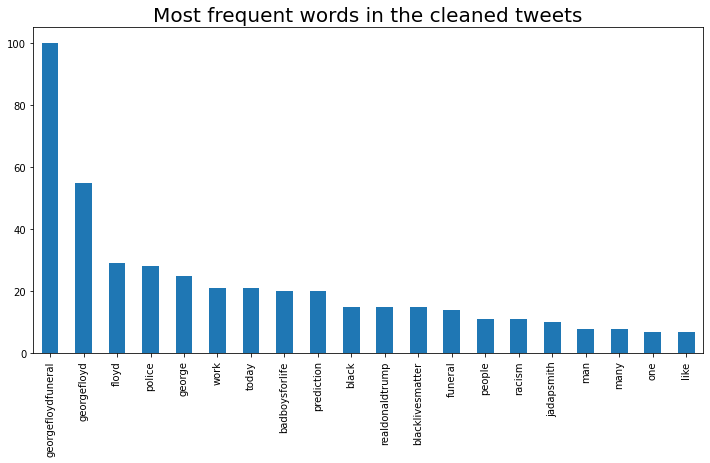

In [13]:
plt.figure(figsize=(12,6))
freq=pd.Series(' '.join(data["cleaned_tweets"]).split()).value_counts()[:20]
freq.plot(kind="bar")
plt.title("Most frequent words in the cleaned tweets",size=20)

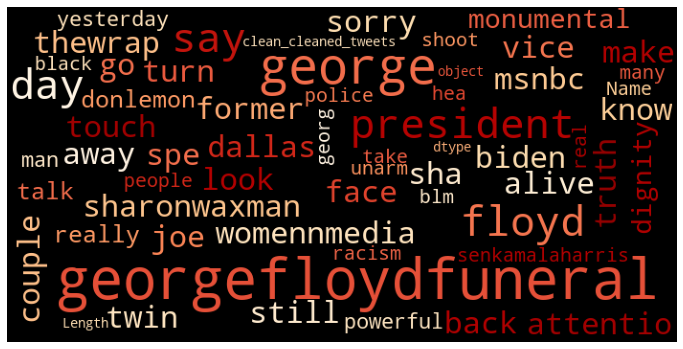

In [14]:
cloud=WordCloud(colormap="OrRd_r",width=700,height=350).generate(str(data["clean_cleaned_tweets"]))
fig=plt.figure(figsize=(12,18))
plt.axis("off")
plt.imshow(cloud)

Now we will use "textblob" for doing our sentiment analysis. 

In [15]:
def analyze_sentiment(tweet):
    analysis = TextBlob(tweet)
    if analysis.sentiment.polarity > 0:     #### For positive sentiment
        return 1
    elif analysis.sentiment.polarity == 0:  ### Neutral
        return 0
    else:
        return -1                           #### Negative sentiment
data['SA'] = data["clean_cleaned_tweets"].apply(lambda x: analyze_sentiment(x))

In [16]:
data.head()

,Tweets,cleaned_tweets,clean_cleaned,clean_cleaned_tweets,SA
0,The truth is IN YOUR FACE. Don't look away!\n#...,truth face look away georgefloydfuneral george...,"[truth, face, look, away, georgefloydfuneral, ...",truth face look away georgefloydfuneral george...,0
1,@WomenNMedia @TheWrap @sharonwaxman Sorry to s...,womennmedia thewrap sharonwaxman sorry say sha...,"[womennmedia, thewrap, sharonwaxman, sorry, sa...",womennmedia thewrap sharonwaxman sorry say sha...,-1
2,Former Vice President Joe Biden made a touchin...,former vice president joe biden made touching ...,"[former, vice, president, joe, biden, made, to...",former vice president joe biden make touch spe...,0
3,@MSNBC Just couple of days back #GeorgeFloydFu...,msnbc couple days back georgefloydfuneral turn...,"[msnbc, couple, days, back, georgefloydfuneral...",msnbc couple days back georgefloydfuneral turn...,0
4,We know you went to Dallas because #GeorgeFloy...,know went dallas georgefloydfuneral got attent...,"[know, went, dallas, georgefloydfuneral, got, ...",know go dallas georgefloydfuneral get attentio...,0


So in the above we can see that we have created a column called "SA", which are the "Sentiments" for the text data. Now we will see how many of them are positive, how many of them are negative and how many of them are neutral.

In [17]:
print(len(data[data["SA"]==0]))  ## Neutral
print(len(data[data["SA"]==-1])) ## Negative
print(len(data[data["SA"]==1]))  ## Positive

105
32
63


Next we will see the percentage value for these.

In [18]:
print(len(data[data["SA"]==0])/len(data["SA"])*100)
print(len(data[data["SA"]==-1])/len(data["SA"])*100)
print(len(data[data["SA"]==1])/len(data["SA"])*100)

52.5
16.0
31.5


Now we will generate wordcloud for the negative sentiments.

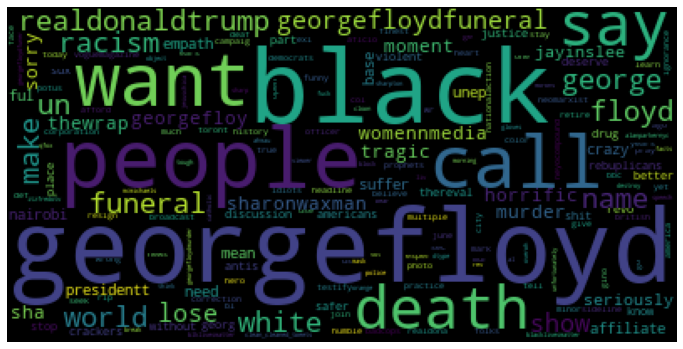

In [19]:
cloud=WordCloud().generate(str(data[data["SA"]==-1]["clean_cleaned_tweets"]))
fig=plt.figure(figsize=(12,14))
plt.axis("off")
plt.imshow(cloud)

Now we will do for the positive sentiments.

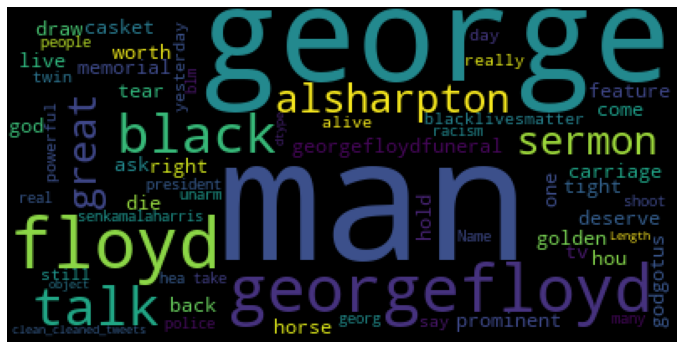

In [20]:
cloud=WordCloud().generate(str(data[data["SA"]==1]["clean_cleaned_tweets"]))
fig=plt.figure(figsize=(12,14))
plt.axis("off")
plt.imshow(cloud)

Finally we will show graphically how many sentiments are negative, how many positive and how many neutral.

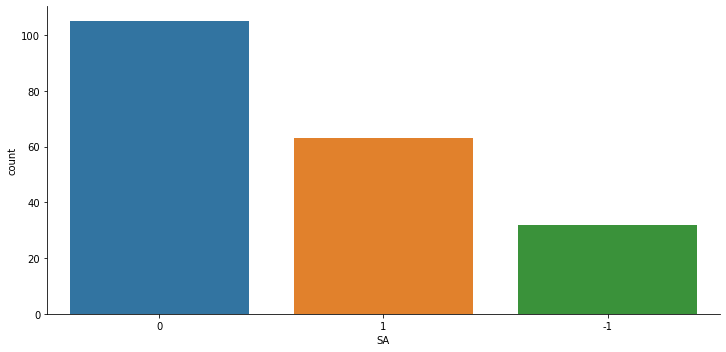

In [21]:
descending_order=data["SA"].value_counts().sort_values(ascending=False).index
sns.catplot(x="SA",data=data,kind="count",height=5,aspect=2,order=descending_order)